# Đồ án Học máy — SV16
## So sánh dự báo Flow giữa hai tập Sensor trong PeMSD3

**Nhóm 2** — Dữ liệu PeMSD (flow, speed, occupancy)

---

## 1. Cài đặt và nhập thư viện

### 1.1. Cài đặt thư viện

In [2]:
# Cài đặt thư viện cần thiết (chạy 1 lần)
!pip install -r requirements.txt
# Hoặc cài riêng:
# !pip install pandas numpy scikit-learn xgboost torch matplotlib seaborn plotly ipywidgets joblib

### 1.2. Nhập thư viện

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import modules của dự án
from modules import data_loader
from modules import eda
from modules import feature_engineering as fe
from modules import models
from modules import visualization as viz
from modules import comparison

# Auto-reload modules khi chỉnh sửa code
%load_ext autoreload
%autoreload 2
%matplotlib inline

print('✅ Đã nhập tất cả thư viện thành công!')

✅ Đã nhập tất cả thư viện thành công!


---
## 2. Kiểm tra GPU

In [4]:
import torch

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device     : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')
else:
    print('⚠️ Không có GPU — LSTM sẽ chạy trên CPU (chậm hơn)')

PyTorch version: 2.12.0+cpu
CUDA available : False
⚠️ Không có GPU — LSTM sẽ chạy trên CPU (chậm hơn)


---
## 3. Cấu hình (CONFIG)

**Tất cả thông số** có thể chỉnh sửa đều nằm ở đây.

In [5]:
CONFIG = {
    # ── Đường dẫn ──
    'data_path': '__datasets-raw/SV16_PeMSD3_sample_8sensors.csv',
    'clean_dir': '__datasets-clean',
    'models_dir': 'models',
    'images_dir': 'resultImages',

    # ── Baselines ──
    'baseline_a_sensors': ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010'],
    'baseline_b_sensors': ['PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014'],

    # ── Chia dữ liệu (Hold-out Split theo thời gian) ──
    'train_ratio': 0.70,
    'valid_ratio': 0.15,
    # test_ratio = 1 - train_ratio - valid_ratio = 0.15

    # ── Feature Engineering ──
    'lag_steps': [1, 2, 3],           # t-5min, t-10min, t-15min
    'lag_columns': ['flow', 'speed', 'occupancy'],
    'rolling_windows': [3, 6, 12],    # 15min, 30min, 1h
    'rolling_columns': ['flow', 'speed'],
    'target_horizon': 3,              # Dự báo flow sau 3 bước = 15 phút

    # ── Modeling ──
    'random_state': 42,
    'model_params': {
        'linear_regression': {},
        'ridge': {'alpha': 1.0},
        'knn': {'n_neighbors': 10, 'weights': 'distance'},
        'decision_tree': {'max_depth': 15},
        'random_forest': {'n_estimators': 100, 'max_depth': 15},
        'xgboost': {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1},
        'lstm': {
            'hidden_size': 64,
            'num_layers': 2,
            'dropout': 0.2,
            'lr': 0.001,
            'epochs': 50,
            'batch_size': 256,
            'patience': 8,
        },
    },
}

print('✅ CONFIG đã thiết lập')
print(f'   Baseline A sensors: {CONFIG["baseline_a_sensors"]}')
print(f'   Baseline B sensors: {CONFIG["baseline_b_sensors"]}')
print(f'   Split: Train {CONFIG["train_ratio"]*100:.0f}% / '
      f'Valid {CONFIG["valid_ratio"]*100:.0f}% / '
      f'Test {(1-CONFIG["train_ratio"]-CONFIG["valid_ratio"])*100:.0f}%')

✅ CONFIG đã thiết lập
   Baseline A sensors: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010']
   Baseline B sensors: ['PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014']
   Split: Train 70% / Valid 15% / Test 15%


---
## 4. Xử lý dữ liệu

### 4.1. Nhập dữ liệu

In [6]:
# Load dữ liệu gốc
df_raw = data_loader.load_raw_data(CONFIG['data_path'])

# Thông tin tổng quan
info = data_loader.get_data_info(df_raw)
data_loader.print_data_info(info)

✅ Đã load 48,384 dòng từ SV16_PeMSD3_sample_8sensors.csv
   Sensors: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010', 'PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014']
   Thời gian: 2024-02-01 00:00:00 → 2024-02-21 23:55:00
📊 THÔNG TIN DATASET
  Tổng số dòng   : 48,384
  Số cột          : 6
  Số sensor       : 8
  Khoảng thời gian: 2024-02-01 00:00:00 → 2024-02-21 23:55:00
  Missing values  : 0

  Số dòng mỗi sensor:
    PEMSD3_007: 6,048 dòng
    PEMSD3_008: 6,048 dòng
    PEMSD3_009: 6,048 dòng
    PEMSD3_010: 6,048 dòng
    PEMSD3_011: 6,048 dòng
    PEMSD3_012: 6,048 dòng
    PEMSD3_013: 6,048 dòng
    PEMSD3_014: 6,048 dòng


In [7]:
# Xem 5 dòng đầu
df_raw.head()

,timestamp,sensor_id,flow,speed,occupancy,district
0,2024-02-01 00:00:00,PEMSD3_007,40.69,53.61,0.3019,D3
1,2024-02-01 00:05:00,PEMSD3_007,35.34,61.20,0.2259,D3
2,2024-02-01 00:10:00,PEMSD3_007,48.23,54.87,0.2803,D3
3,2024-02-01 00:15:00,PEMSD3_007,40.01,60.65,0.2086,D3
4,2024-02-01 00:20:00,PEMSD3_007,47.15,52.11,0.3292,D3


In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  48384 non-null  datetime64[us]
 1   sensor_id  48384 non-null  str           
 2   flow       48384 non-null  float64       
 3   speed      48384 non-null  float64       
 4   occupancy  48384 non-null  float64       
 5   district   48384 non-null  str           
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 2.2 MB


### 4.2. Thống kê mô tả & EDA

In [31]:
# Thống kê mô tả per sensor
stats = eda.describe_per_sensor(df_raw)
stats.T

sensor_id        PEMSD3_007  PEMSD3_008  PEMSD3_009  PEMSD3_010  PEMSD3_011  \
flow      count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean        73.67       78.80       84.62       90.51       67.70   
          std         33.60       35.88       38.37       40.73       31.36   
          min          5.00        5.00        5.00       12.60        5.00   
          25%         47.04       50.17       54.27       58.01       43.02   
          50%         65.44       69.22       73.24       78.13       59.78   
          75%         99.02      105.42      114.11      122.19       90.94   
          max        174.09      188.52      218.03      207.37      172.89   
speed     count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean        51.80       50.90       49.80       48.66       52.86   
          std          6.74        7.01        7.50        7.93        6.39   
          min         29.20       26.01       24.20       22.82       30.01   
          25%         47.08       46.01       44.41       42.95       48.49   
          50%         52.73       52.06       51.12       50.16       53.62   
          75%         56.88       56.21       55.49       54.80       57.60   
          max         69.39       68.14       68.38       69.24       71.60   
occupancy count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean         0.44        0.47        0.50        0.53        0.40   
          std          0.20        0.21        0.22        0.23        0.19   
          min          0.02        0.02        0.04        0.04        0.02   
          25%          0.28        0.30        0.32        0.34        0.25   
          50%          0.39        0.41        0.44        0.47        0.36   
          75%          0.59        0.63        0.68        0.73        0.54   
          max          0.92        0.92        0.92        0.92        0.92   

sensor_id        PEMSD3_012  PEMSD3_013  PEMSD3_014  
flow      count     6048.00     6048.00     6048.00  
          mean        73.24       78.93       84.90  
          std         33.60       36.12       38.05  
          min          5.00        5.00       11.59  
          25%         46.61       50.17       54.75  
          50%         64.28       69.01       73.96  
          75%         98.63      106.52      113.83  
          max        170.33      189.50      193.02  
speed     count     6048.00     6048.00     6048.00  
          mean        51.83       50.81       49.80  
          std          6.76        7.14        7.48  
          min         31.24       26.90       27.38  
          25%         47.02       45.72       44.43  
          50%         52.80       51.96       51.11  
          75%         56.88       56.22       55.53  
          max         68.65       70.49       68.01  
occupancy count     6048.00     6048.00     6048.00  
          mean         0.43        0.47        0.50  
          std          0.20        0.21        0.22  
          min          0.03        0.02        0.06  
          25%          0.28        0.30        0.32  
          50%          0.38        0.41        0.44  
          75%          0.59        0.63        0.67  
          max          0.92        0.92        0.92

In [10]:
# Kiểm tra missing data
missing_report = eda.check_missing(df_raw)
missing_report

,sensor_id,n_rows,n_null_values,missing_rate_%,n_time_gaps
0,PEMSD3_007,6048,0,0.0,0
1,PEMSD3_008,6048,0,0.0,0
2,PEMSD3_009,6048,0,0.0,0
3,PEMSD3_010,6048,0,0.0,0
4,PEMSD3_011,6048,0,0.0,0
5,PEMSD3_012,6048,0,0.0,0
6,PEMSD3_013,6048,0,0.0,0
7,PEMSD3_014,6048,0,0.0,0


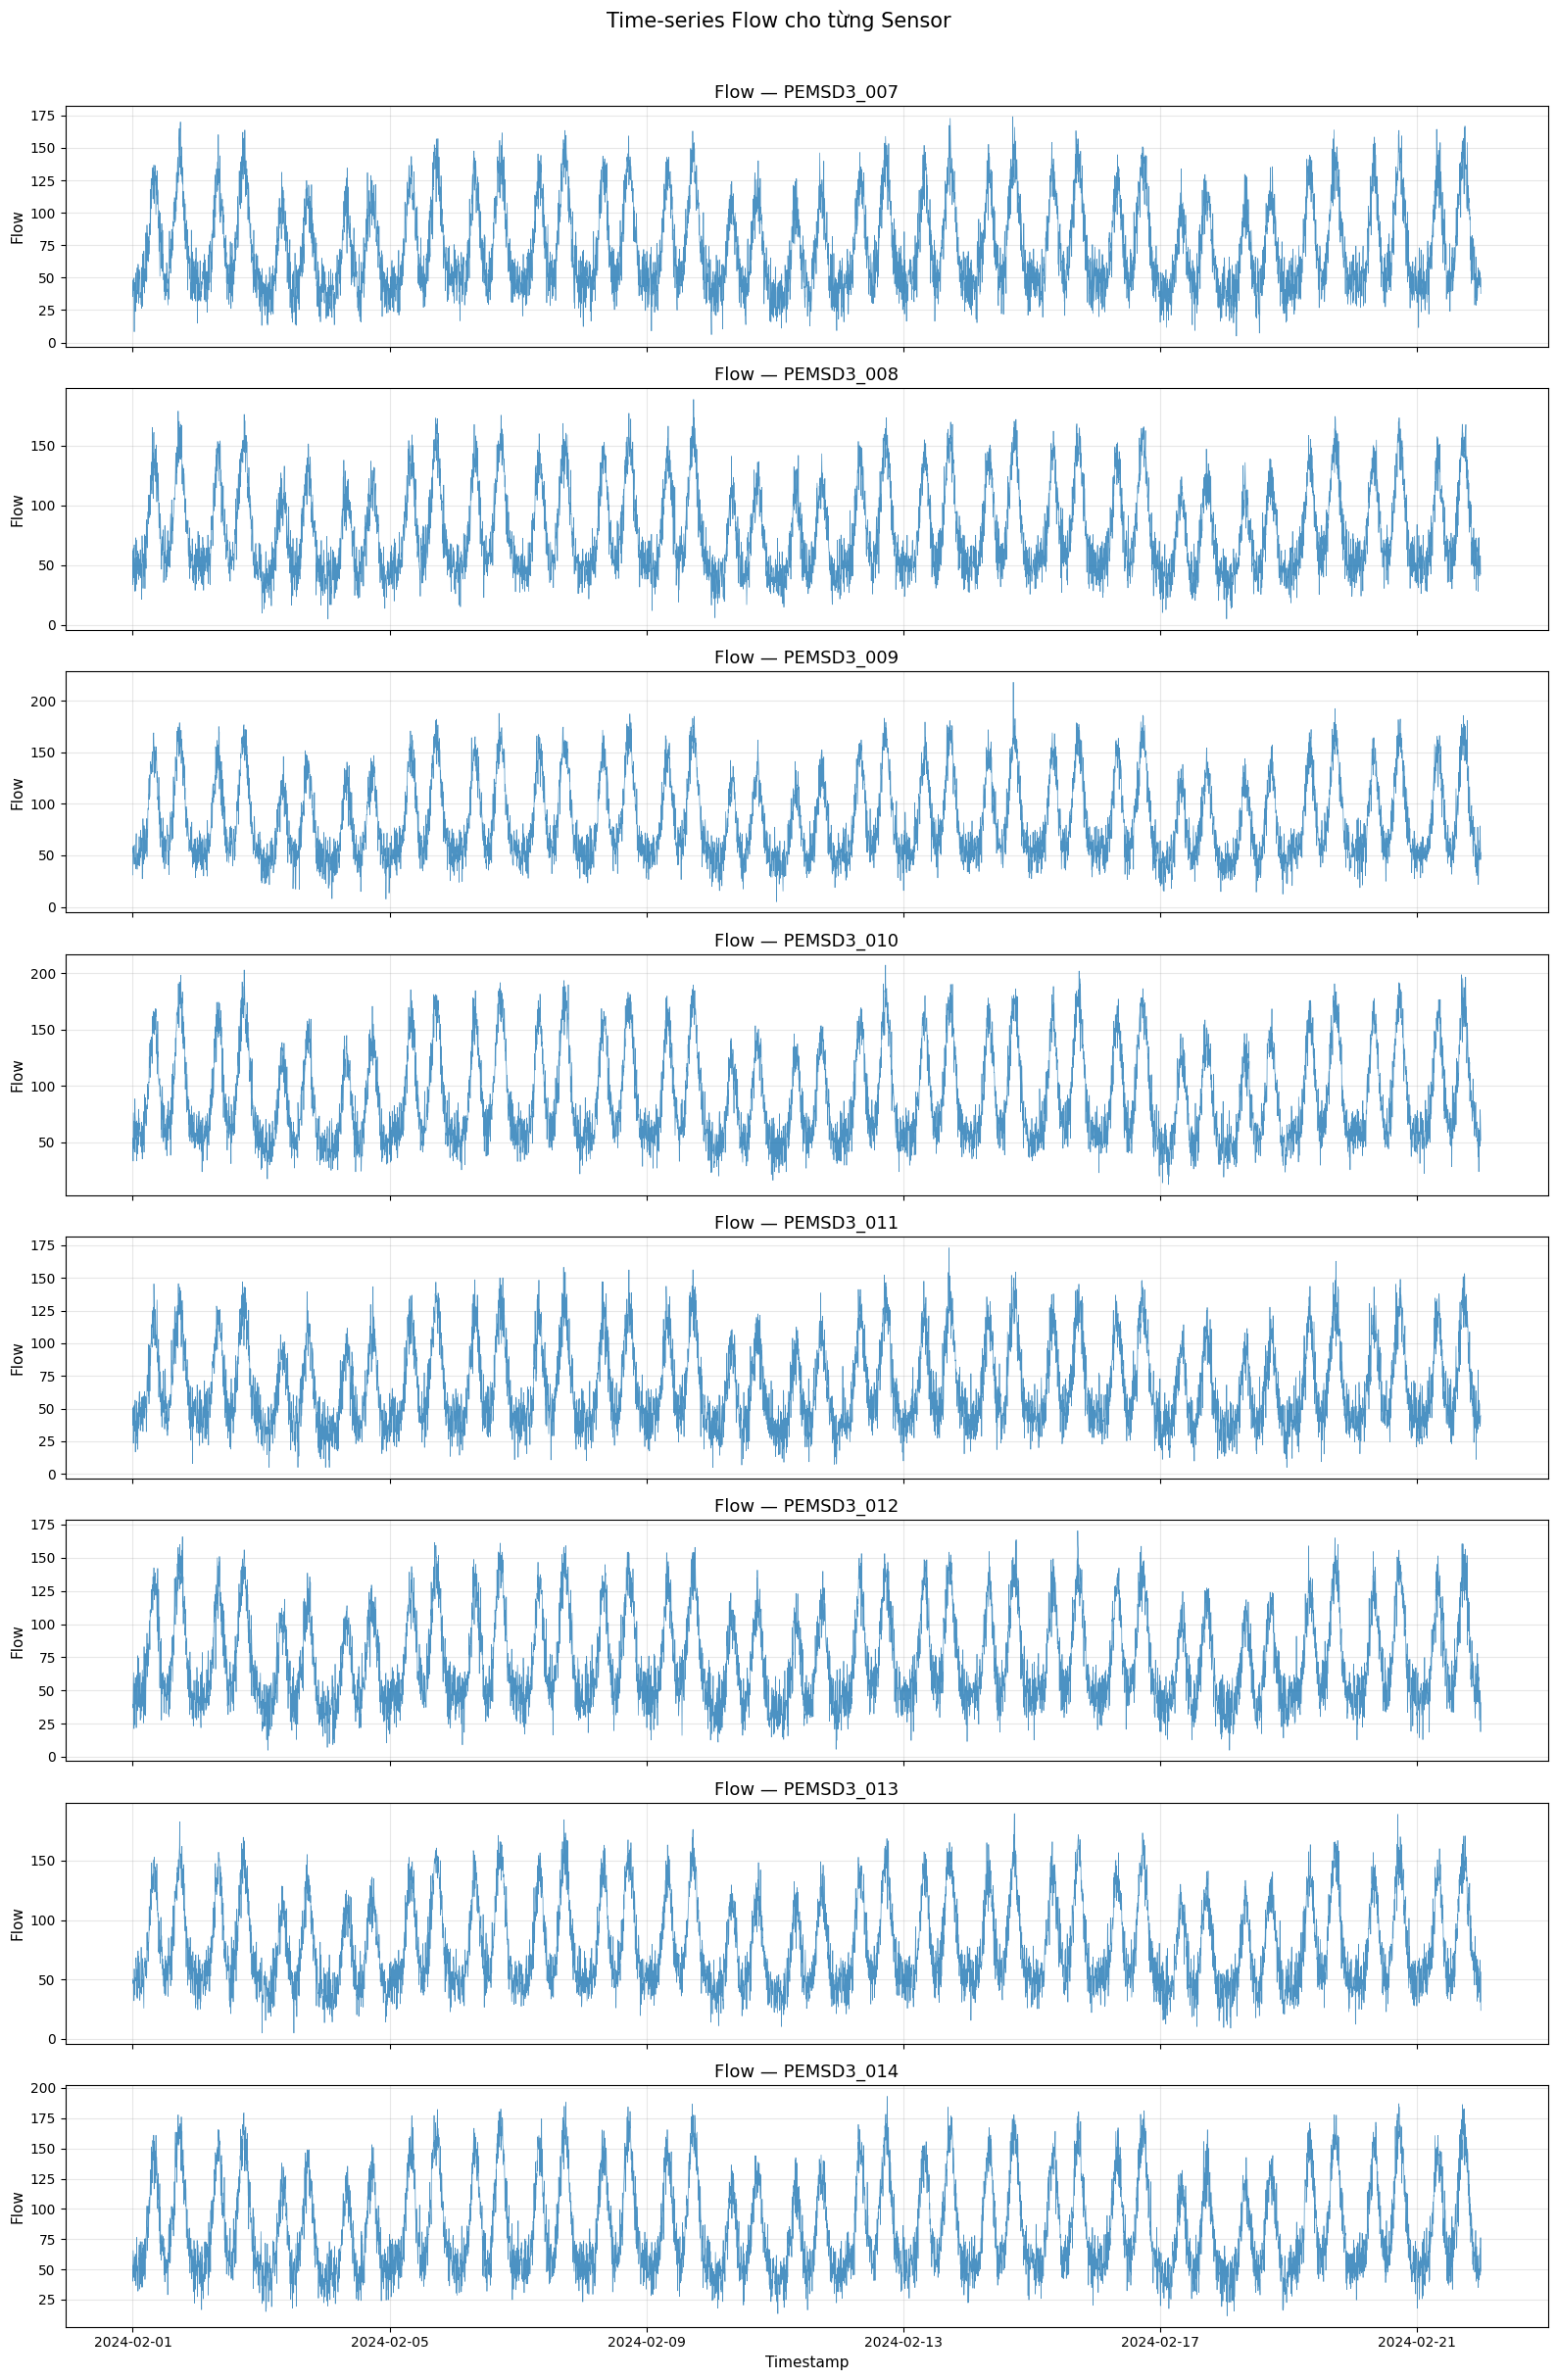

In [11]:
# Biểu đồ time-series flow cho từng sensor
eda.plot_timeseries_flow(df_raw, save_dir=CONFIG['images_dir'])

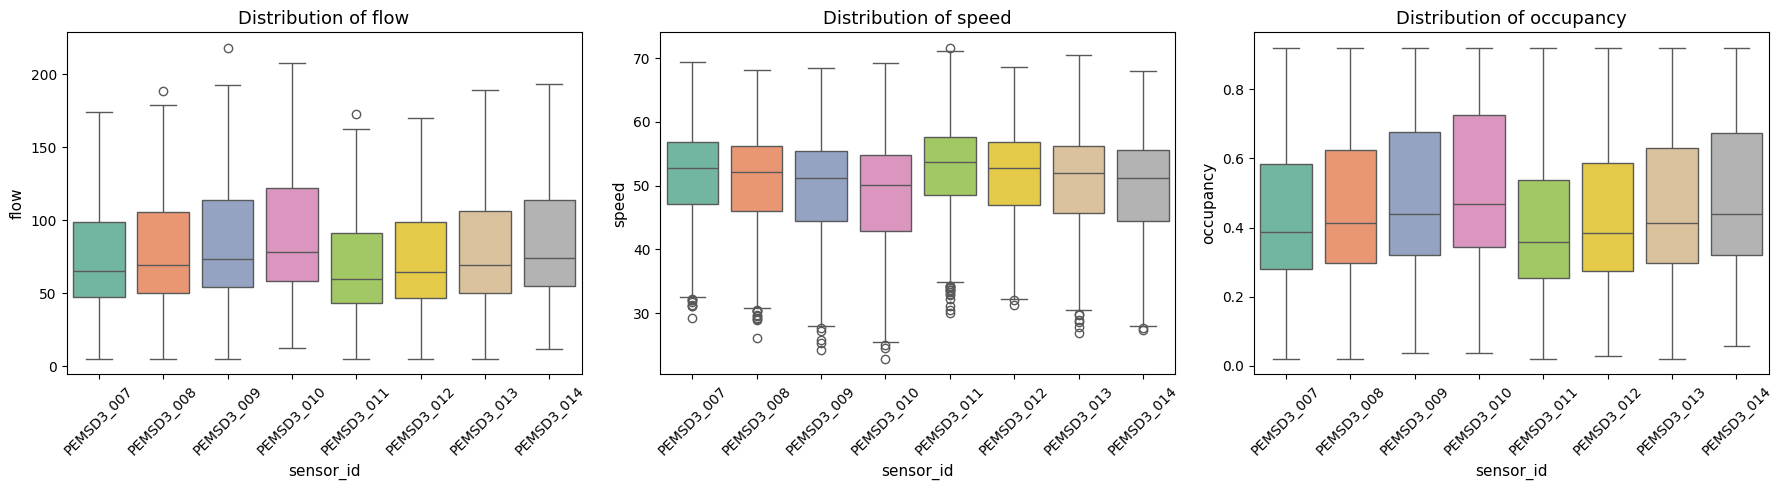

In [12]:
# Distribution boxplot
eda.plot_distribution(df_raw, save_dir=CONFIG['images_dir'])

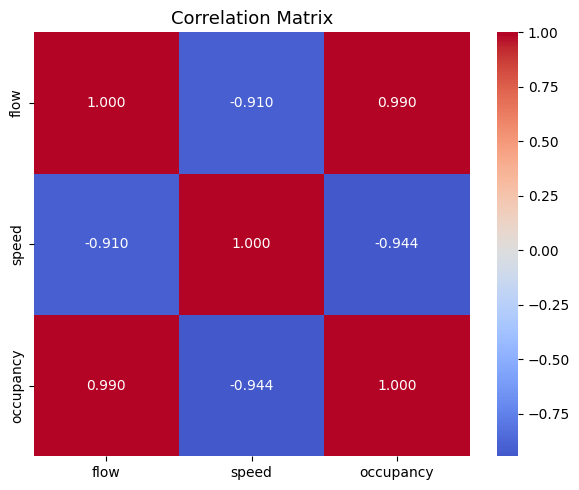

In [13]:
# Correlation heatmap
eda.plot_correlation(df_raw, save_dir=CONFIG['images_dir'])

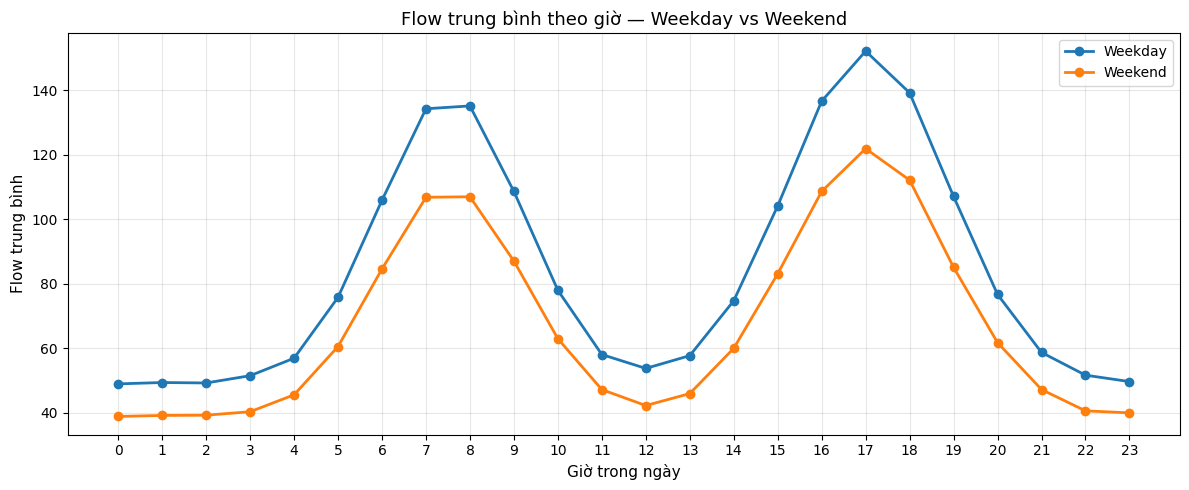

In [14]:
# Hourly pattern: Weekday vs Weekend
eda.plot_hourly_pattern(df_raw, save_dir=CONFIG['images_dir'])

### 4.3. Feature Engineering

In [15]:
# Tạo toàn bộ features: time + lag + rolling + target
df_featured = fe.prepare_all_features(df_raw, CONFIG)

# Kiểm tra kết quả
print(f'\nShape sau feature engineering: {df_featured.shape}')
print(f'Columns: {list(df_featured.columns)}')
df_featured.head()

✅ Đã thêm time features: hour, weekday, is_weekend, time_slot
✅ Đã thêm 9 lag features (lags=[1, 2, 3], cols=['flow', 'speed', 'occupancy'])
✅ Đã thêm 12 rolling features (windows=[3, 6, 12])
✅ Đã tạo target: flow_target (t+3 = 15 phút)
✅ Drop NaN: 48,384 → 48,336 dòng (mất 48)

Shape sau feature engineering: (48336, 32)
Columns: ['timestamp', 'sensor_id', 'flow', 'speed', 'occupancy', 'district', 'hour', 'weekday', 'is_weekend', 'time_slot', 'flow_lag_1', 'flow_lag_2', 'flow_lag_3', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'flow_roll_mean_3', 'flow_roll_std_3', 'flow_roll_mean_6', 'flow_roll_std_6', 'flow_roll_mean_12', 'flow_roll_std_12', 'speed_roll_mean_3', 'speed_roll_std_3', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_roll_std_12', 'flow_target']


,timestamp,sensor_id,flow,speed,occupancy,district,hour,weekday,is_weekend,time_slot,...,flow_roll_std_6,flow_roll_mean_12,flow_roll_std_12,speed_roll_mean_3,speed_roll_std_3,speed_roll_mean_6,speed_roll_std_6,speed_roll_mean_12,speed_roll_std_12,flow_target
0,2024-02-01 00:15:00,PEMSD3_007,40.01,60.65,0.2086,D3,0,3,0,0,...,5.334369,41.067500,5.334369,58.906667,3.506656,57.582500,3.900183,57.582500,3.900183,49.69
1,2024-02-01 00:20:00,PEMSD3_007,47.15,52.11,0.3292,D3,0,3,0,0,...,5.361061,42.284000,5.361061,55.876667,4.358088,56.488000,4.171117,56.488000,4.171117,8.35
2,2024-02-01 00:25:00,PEMSD3_007,41.18,58.69,0.2528,D3,0,3,0,0,...,4.816214,42.100000,4.816214,57.150000,4.473433,56.855000,3.837540,56.855000,3.837540,46.15
3,2024-02-01 00:30:00,PEMSD3_007,49.69,50.51,0.3674,D3,0,3,0,0,...,5.623159,43.184286,5.249730,53.770000,4.335297,56.338333,4.511339,55.948571,4.245415,40.48
4,2024-02-01 00:35:00,PEMSD3_007,8.35,62.12,0.0822,D3,0,3,0,0,...,15.562933,38.830000,13.240128,57.106667,5.964749,56.491667,4.720417,56.720000,4.495506,42.62


In [16]:
# Danh sách feature columns sẽ dùng cho modeling
FEATURE_COLS = fe.get_feature_columns(CONFIG)
TARGET_COL = 'flow_target'

print(f'Số features: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')
print(f'Target: {TARGET_COL}')

Số features: 24
Features: ['flow_lag_1', 'flow_lag_2', 'flow_lag_3', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'flow_roll_mean_3', 'flow_roll_std_3', 'flow_roll_mean_6', 'flow_roll_std_6', 'flow_roll_mean_12', 'flow_roll_std_12', 'speed_roll_mean_3', 'speed_roll_std_3', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_roll_std_12', 'hour', 'weekday', 'is_weekend']
Target: flow_target


### 4.4. Chia Baseline A & Baseline B

In [17]:
df_baseline_a, df_baseline_b = data_loader.split_baselines(
    df_featured,
    CONFIG['baseline_a_sensors'],
    CONFIG['baseline_b_sensors'],
)

✅ Chia Baselines:
   Baseline A: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010'] → 24,168 dòng
   Baseline B: ['PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014'] → 24,168 dòng


### 4.5. Hold-out Split (Train 70% / Valid 15% / Test 15%)

In [18]:
# Baseline A
print('── Baseline A ──')
train_a, valid_a, test_a = fe.holdout_split(
    df_baseline_a, CONFIG['train_ratio'], CONFIG['valid_ratio']
)

# Baseline B
print('\n── Baseline B ──')
train_b, valid_b, test_b = fe.holdout_split(
    df_baseline_b, CONFIG['train_ratio'], CONFIG['valid_ratio']
)

── Baseline A ──
✅ Hold-out Split (theo thời gian, per sensor):
   Train : 16,916 dòng (70%)
   Valid : 3,624 dòng (15%)
   Test  : 3,628 dòng (15%)

── Baseline B ──
✅ Hold-out Split (theo thời gian, per sensor):
   Train : 16,916 dòng (70%)
   Valid : 3,624 dòng (15%)
   Test  : 3,628 dòng (15%)


In [19]:
# Chuẩn bị X, y cho modeling
X_train_a, y_train_a = train_a[FEATURE_COLS].values, train_a[TARGET_COL].values
X_valid_a, y_valid_a = valid_a[FEATURE_COLS].values, valid_a[TARGET_COL].values
X_test_a,  y_test_a  = test_a[FEATURE_COLS].values,  test_a[TARGET_COL].values

X_train_b, y_train_b = train_b[FEATURE_COLS].values, train_b[TARGET_COL].values
X_valid_b, y_valid_b = valid_b[FEATURE_COLS].values, valid_b[TARGET_COL].values
X_test_b,  y_test_b  = test_b[FEATURE_COLS].values,  test_b[TARGET_COL].values

print(f'Baseline A — X_train: {X_train_a.shape}, X_valid: {X_valid_a.shape}, X_test: {X_test_a.shape}')
print(f'Baseline B — X_train: {X_train_b.shape}, X_valid: {X_valid_b.shape}, X_test: {X_test_b.shape}')

Baseline A — X_train: (16916, 24), X_valid: (3624, 24), X_test: (3628, 24)
Baseline B — X_train: (16916, 24), X_valid: (3624, 24), X_test: (3628, 24)


In [20]:
# Lưu datasets đã xử lý (tuỳ chọn)
import os
os.makedirs(CONFIG['clean_dir'], exist_ok=True)

train_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_train.csv", index=False)
valid_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_valid.csv", index=False)
test_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_test.csv", index=False)
train_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_train.csv", index=False)
valid_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_valid.csv", index=False)
test_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_test.csv", index=False)

print(f'✅ Đã lưu datasets vào {CONFIG["clean_dir"]}/')

✅ Đã lưu datasets vào __datasets-clean/


---
## 5. Xây dựng mô hình Baseline

Huấn luyện **7 mô hình** cho mỗi baseline:
1. Linear Regression
2. Ridge Regression
3. KNN Regressor
4. Decision Tree Regressor
5. Random Forest Regressor
6. XGBoost Regressor
7. LSTM

### 5.1. Huấn luyện 7 mô hình cho Baseline A

In [21]:
models_a = models.get_models(CONFIG)
results_a, trained_a = models.train_and_evaluate(
    models_a, X_train_a, y_train_a,
    X_valid_a, y_valid_a,
    X_test_a, y_test_a,
    baseline_name='Baseline_A'
)
results_a


🚀 HUẤN LUYỆN Baseline_A — 7 mô hình

--- 1_LinearRegression ---
   Valid — MAE=11.54  RMSE=14.44  R²=0.8457
   Test  — MAE=11.61  RMSE=14.51  R²=0.8611

--- 2_Ridge ---
   Valid — MAE=11.54  RMSE=14.44  R²=0.8457
   Test  — MAE=11.61  RMSE=14.51  R²=0.8611

--- 3_KNN ---
   Valid — MAE=11.60  RMSE=14.47  R²=0.8451
   Test  — MAE=11.23  RMSE=14.12  R²=0.8686

--- 4_DecisionTree ---
   Valid — MAE=13.55  RMSE=17.10  R²=0.7835
   Test  — MAE=13.75  RMSE=17.70  R²=0.7935

--- 5_RandomForest ---
   Valid — MAE=10.47  RMSE=13.11  R²=0.8729
   Test  — MAE=10.28  RMSE=12.96  R²=0.8893

--- 6_XGBoost ---
   Valid — MAE=10.53  RMSE=13.17  R²=0.8716
   Test  — MAE=10.50  RMSE=13.16  R²=0.8857

--- 7_LSTM ---
   Epoch 10/50 — train_loss=393.7029 — val_loss=231.1069
   Epoch 20/50 — train_loss=324.6532 — val_loss=202.4162
   Epoch 30/50 — train_loss=323.5278 — val_loss=196.0728
   Epoch 40/50 — train_loss=321.1668 — val_loss=193.5372
   Epoch 50/50 — train_loss=314.2034 — val_loss=194.2650
   Vali

,model,baseline,test_MAE,test_RMSE,test_MAPE,test_R2,valid_MAE,valid_RMSE,valid_MAPE,valid_R2
0,1_LinearRegression,Baseline_A,11.6127,14.5131,17.5158,0.8611,11.5412,14.4384,20.3132,0.8457
1,2_Ridge,Baseline_A,11.6126,14.5126,17.5153,0.8611,11.5409,14.4381,20.3129,0.8457
2,3_KNN,Baseline_A,11.2331,14.1150,16.6933,0.8686,11.5967,14.4663,20.3523,0.8451
3,4_DecisionTree,Baseline_A,13.7488,17.6974,20.1075,0.7935,13.5456,17.1032,22.8035,0.7835
4,5_RandomForest,Baseline_A,10.2820,12.9561,15.4399,0.8893,10.4680,13.1072,18.4516,0.8729
5,6_XGBoost,Baseline_A,10.5036,13.1636,15.7331,0.8857,10.5298,13.1738,18.4675,0.8716
6,7_LSTM,Baseline_A,10.9068,13.7270,16.2894,0.8757,11.0638,13.8664,19.3034,0.8577


### 5.2. Huấn luyện 7 mô hình cho Baseline B

In [22]:
models_b = models.get_models(CONFIG)
results_b, trained_b = models.train_and_evaluate(
    models_b, X_train_b, y_train_b,
    X_valid_b, y_valid_b,
    X_test_b, y_test_b,
    baseline_name='Baseline_B'
)
results_b


🚀 HUẤN LUYỆN Baseline_B — 7 mô hình

--- 1_LinearRegression ---
   Valid — MAE=11.29  RMSE=14.16  R²=0.8275
   Test  — MAE=11.69  RMSE=14.56  R²=0.8434

--- 2_Ridge ---
   Valid — MAE=11.29  RMSE=14.16  R²=0.8275
   Test  — MAE=11.69  RMSE=14.56  R²=0.8435

--- 3_KNN ---
   Valid — MAE=11.40  RMSE=14.30  R²=0.8242
   Test  — MAE=11.58  RMSE=14.50  R²=0.8448

--- 4_DecisionTree ---
   Valid — MAE=13.71  RMSE=17.41  R²=0.7393
   Test  — MAE=13.77  RMSE=17.65  R²=0.7698

--- 5_RandomForest ---
   Valid — MAE=10.34  RMSE=12.91  R²=0.8567
   Test  — MAE=10.47  RMSE=13.17  R²=0.8719

--- 6_XGBoost ---
   Valid — MAE=10.38  RMSE=12.99  R²=0.8549
   Test  — MAE=10.69  RMSE=13.50  R²=0.8654

--- 7_LSTM ---
   Epoch 10/50 — train_loss=371.5401 — val_loss=219.1918
   Epoch 20/50 — train_loss=318.4727 — val_loss=192.8588
   Epoch 30/50 — train_loss=309.7053 — val_loss=189.7481
   ⏹ Early stopping tại epoch 31
   Valid — MAE=10.93  RMSE=13.73  R²=0.8378
   Test  — MAE=11.26  RMSE=14.12  R²=0.8528


,model,baseline,test_MAE,test_RMSE,test_MAPE,test_R2,valid_MAE,valid_RMSE,valid_MAPE,valid_R2
0,1_LinearRegression,Baseline_B,11.6932,14.5596,19.5611,0.8434,11.2873,14.1634,21.2025,0.8275
1,2_Ridge,Baseline_B,11.6930,14.5592,19.5606,0.8435,11.2869,14.1633,21.2018,0.8275
2,3_KNN,Baseline_B,11.5761,14.4955,19.2069,0.8448,11.3991,14.3005,21.4487,0.8242
3,4_DecisionTree,Baseline_B,13.7738,17.6546,22.3851,0.7698,13.7066,17.4148,24.5109,0.7393
4,5_RandomForest,Baseline_B,10.4661,13.1696,17.6684,0.8719,10.3398,12.9113,19.5740,0.8567
5,6_XGBoost,Baseline_B,10.6851,13.4997,17.9125,0.8654,10.3787,12.9905,19.4926,0.8549
6,7_LSTM,Baseline_B,11.2633,14.1181,18.7518,0.8528,10.9257,13.7331,20.2832,0.8378


### 5.3. Lưu mô hình

In [23]:
models.save_models(trained_a, CONFIG['models_dir'], 'Baseline_A')
models.save_models(trained_b, CONFIG['models_dir'], 'Baseline_B')

✅ Đã lưu 7 mô hình vào models\Baseline_A
✅ Đã lưu 7 mô hình vào models\Baseline_B


### 5.4. Biểu đồ Actual vs Predicted — Baseline A

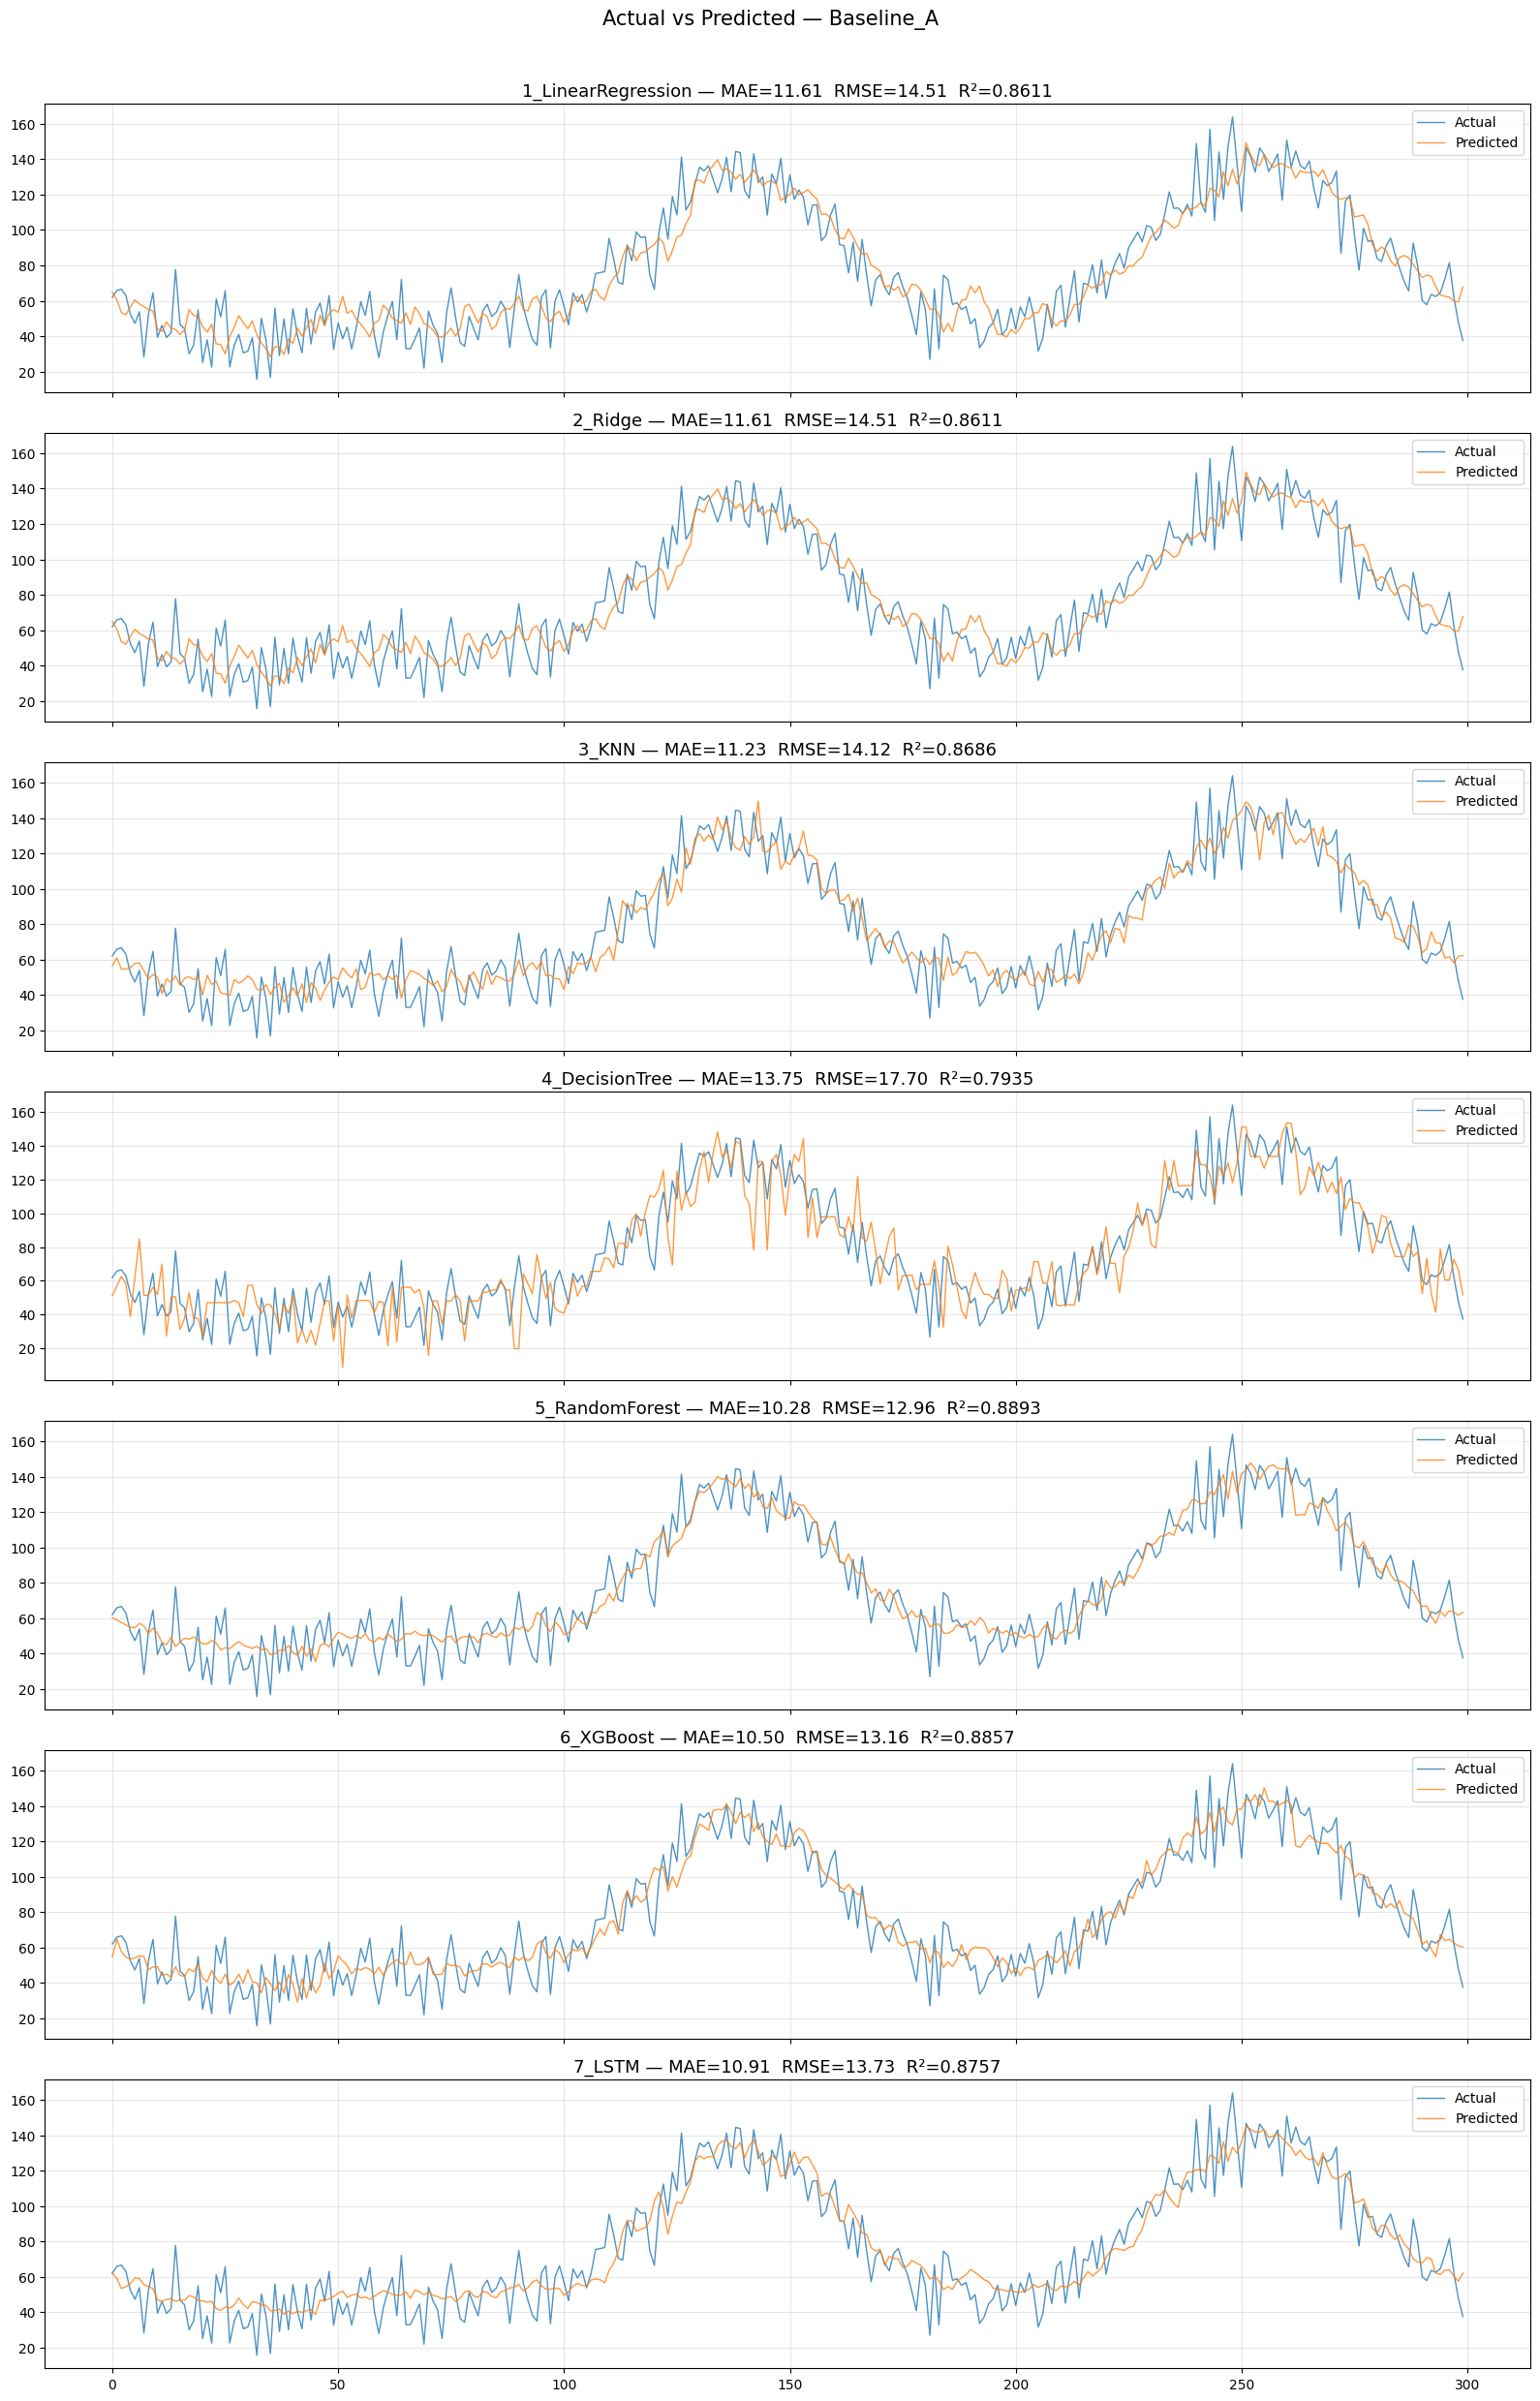

In [24]:
viz.plot_all_model_results(
    trained_a, y_test_a,
    baseline_name='Baseline_A',
    save_dir=CONFIG['images_dir'],
    n_points=300
)

### 5.5. Biểu đồ Actual vs Predicted — Baseline B

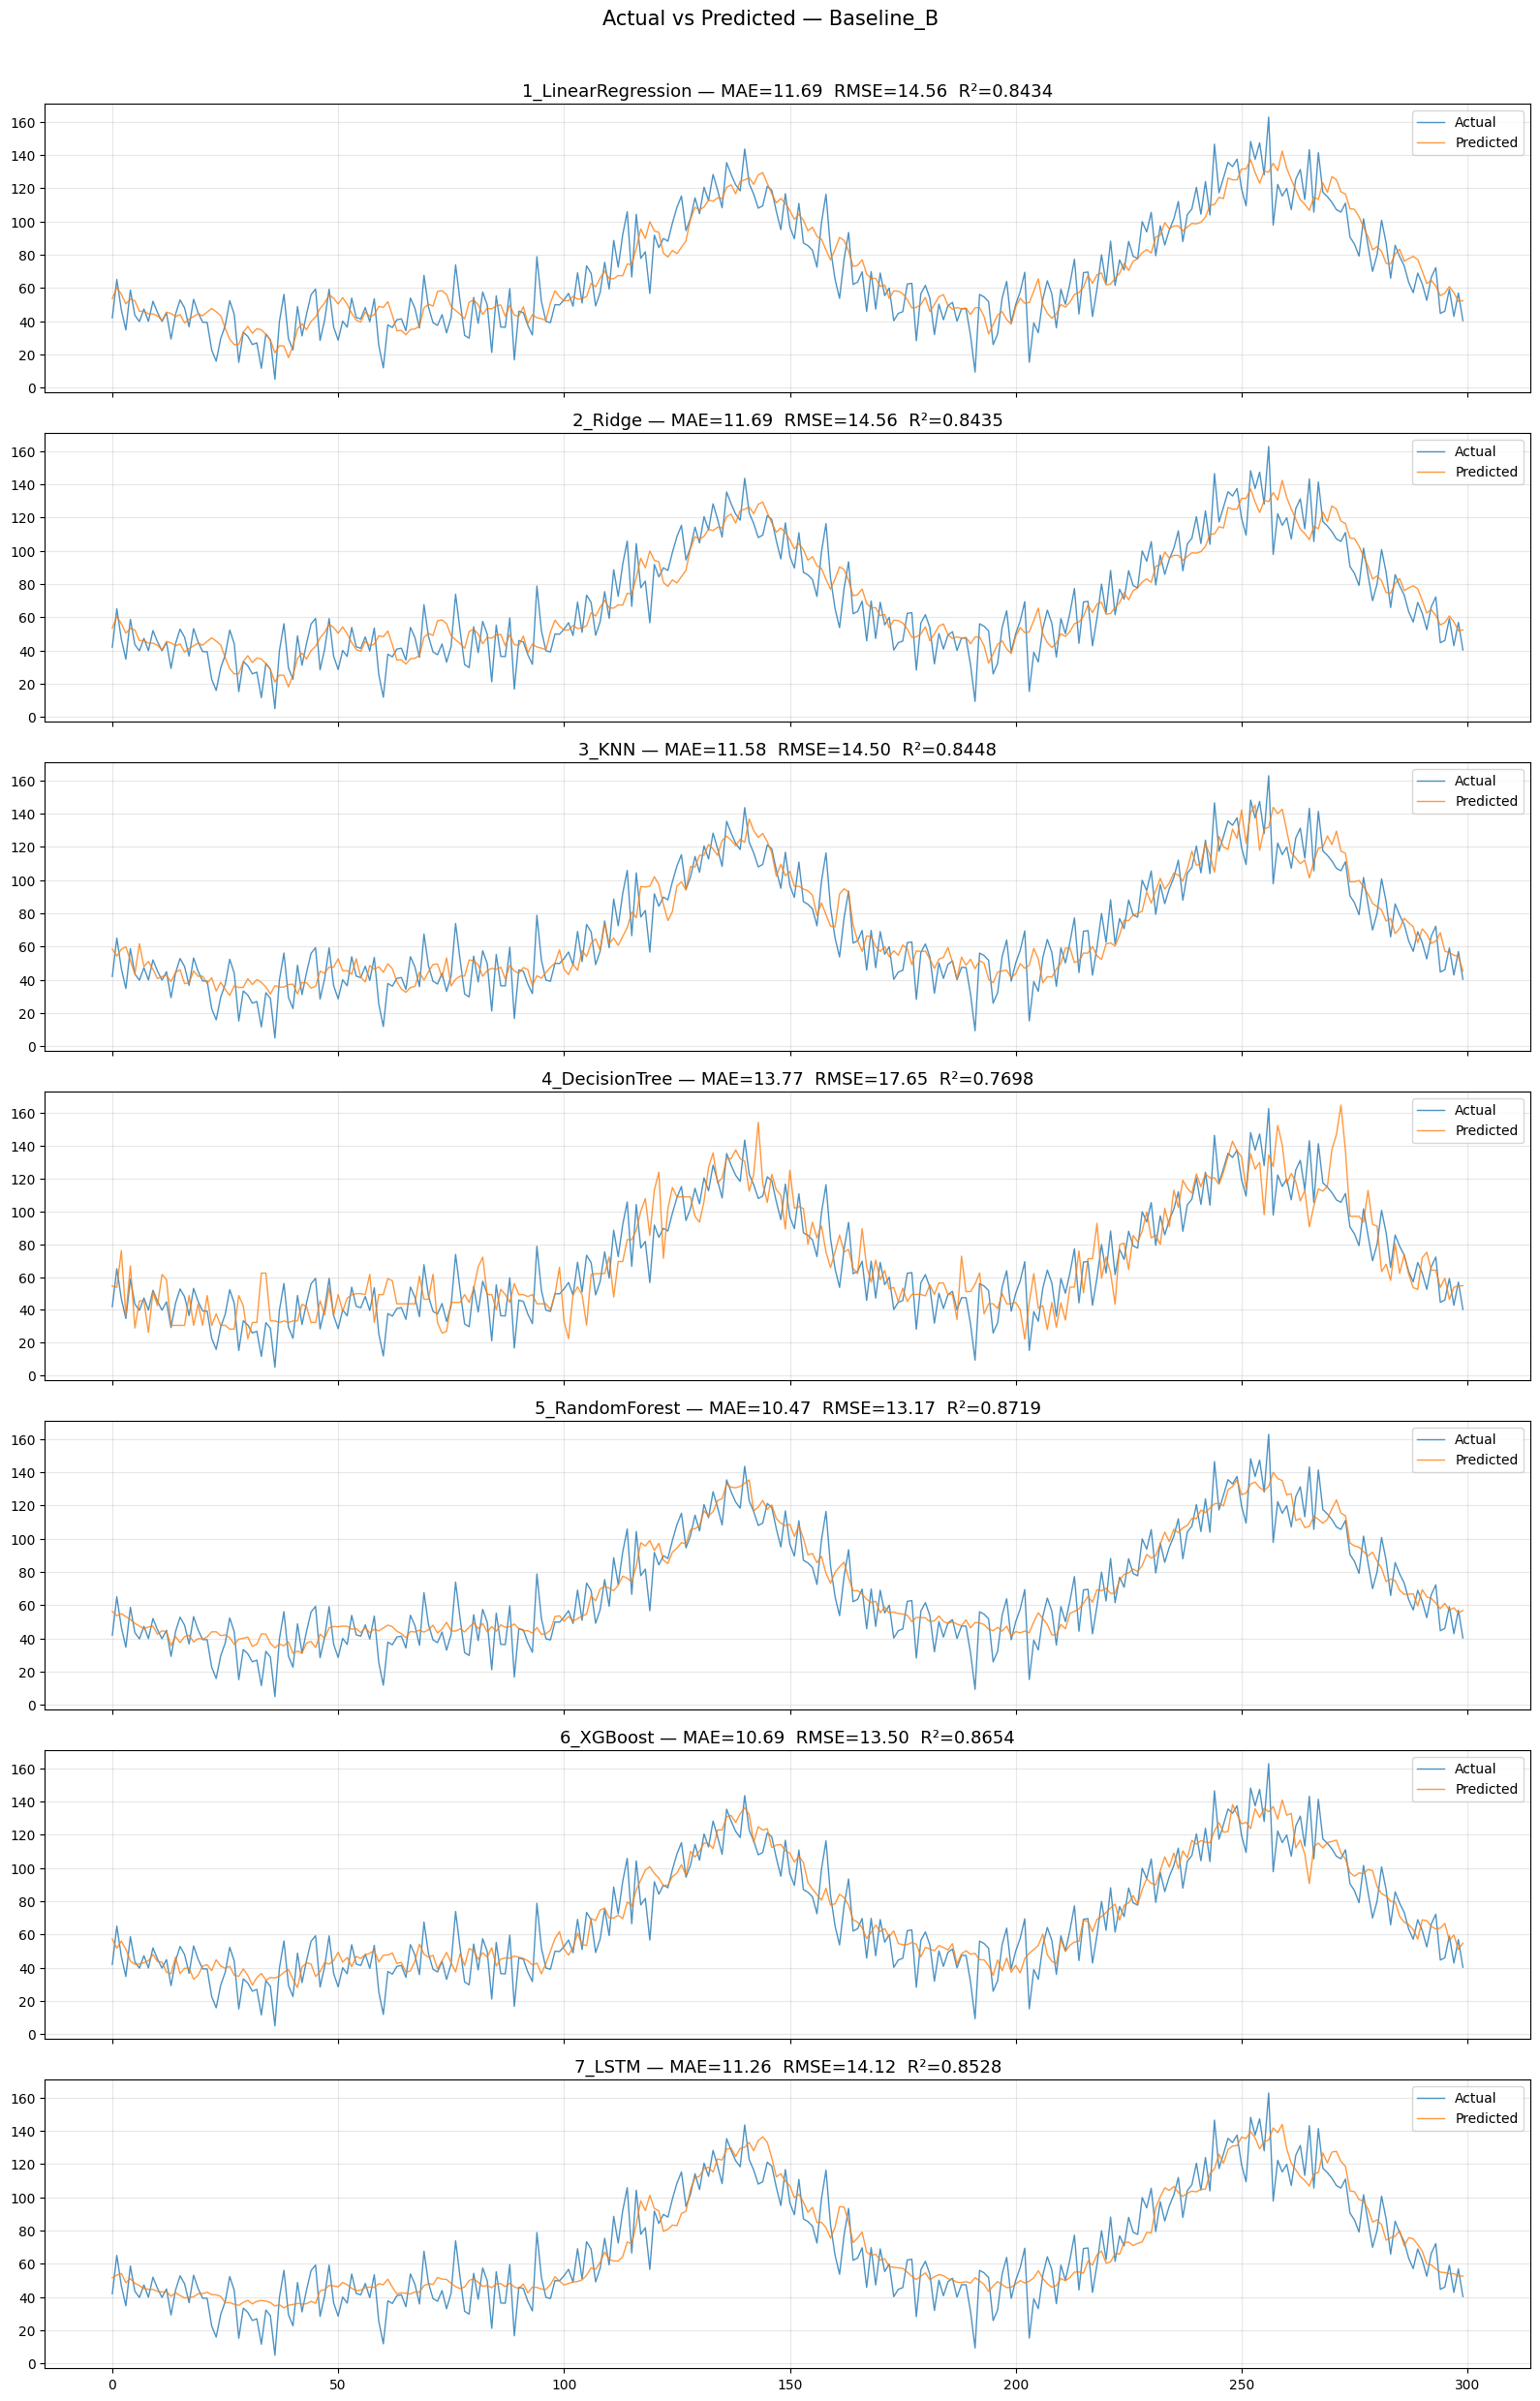

In [25]:
viz.plot_all_model_results(
    trained_b, y_test_b,
    baseline_name='Baseline_B',
    save_dir=CONFIG['images_dir'],
    n_points=300
)

---
## 6. So sánh 2 Baseline

### 6.1. Bảng tổng hợp metrics

In [26]:
compare_table = comparison.create_comparison_table(results_a, results_b)
compare_table

,model,A_MAE,B_MAE,A_RMSE,B_RMSE,A_MAPE,B_MAPE,A_R2,B_R2,better
0,1_LinearRegression,11.6127,11.6932,14.5131,14.5596,17.5158,19.5611,0.8611,0.8434,A
1,2_Ridge,11.6126,11.6930,14.5126,14.5592,17.5153,19.5606,0.8611,0.8435,A
2,3_KNN,11.2331,11.5761,14.1150,14.4955,16.6933,19.2069,0.8686,0.8448,A
3,4_DecisionTree,13.7488,13.7738,17.6974,17.6546,20.1075,22.3851,0.7935,0.7698,A
4,5_RandomForest,10.2820,10.4661,12.9561,13.1696,15.4399,17.6684,0.8893,0.8719,A
5,6_XGBoost,10.5036,10.6851,13.1636,13.4997,15.7331,17.9125,0.8857,0.8654,A
6,7_LSTM,10.9068,11.2633,13.7270,14.1181,16.2894,18.7518,0.8757,0.8528,A


### 6.2. Biểu đồ so sánh

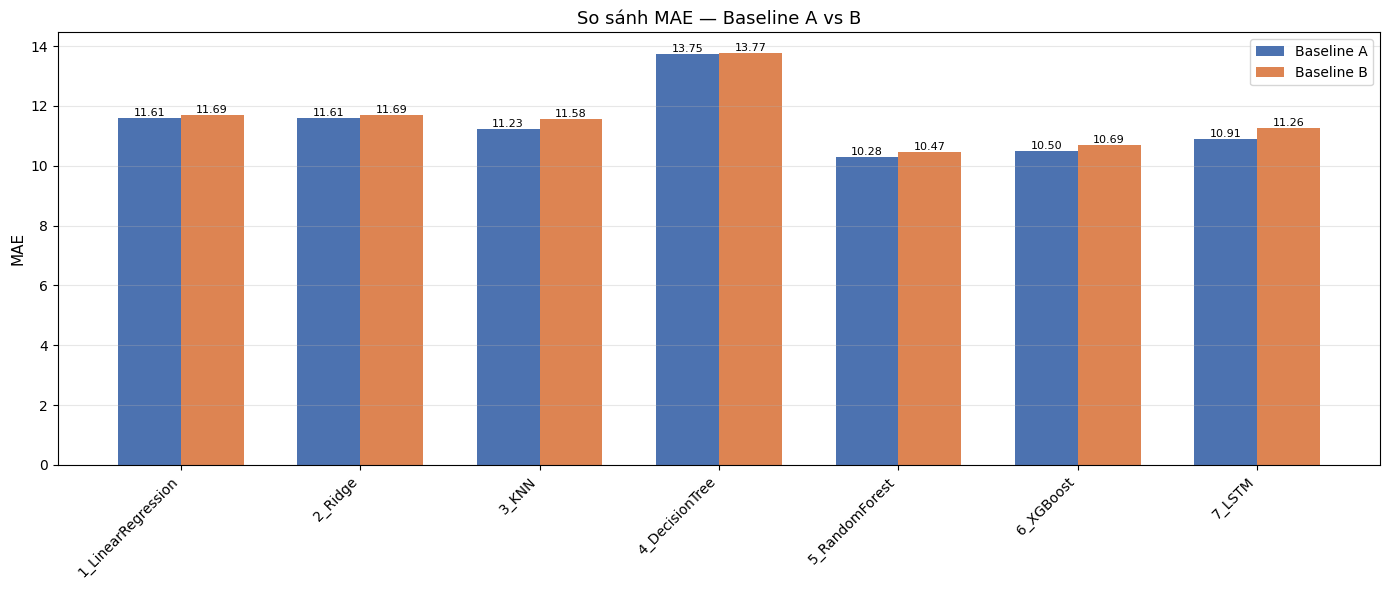

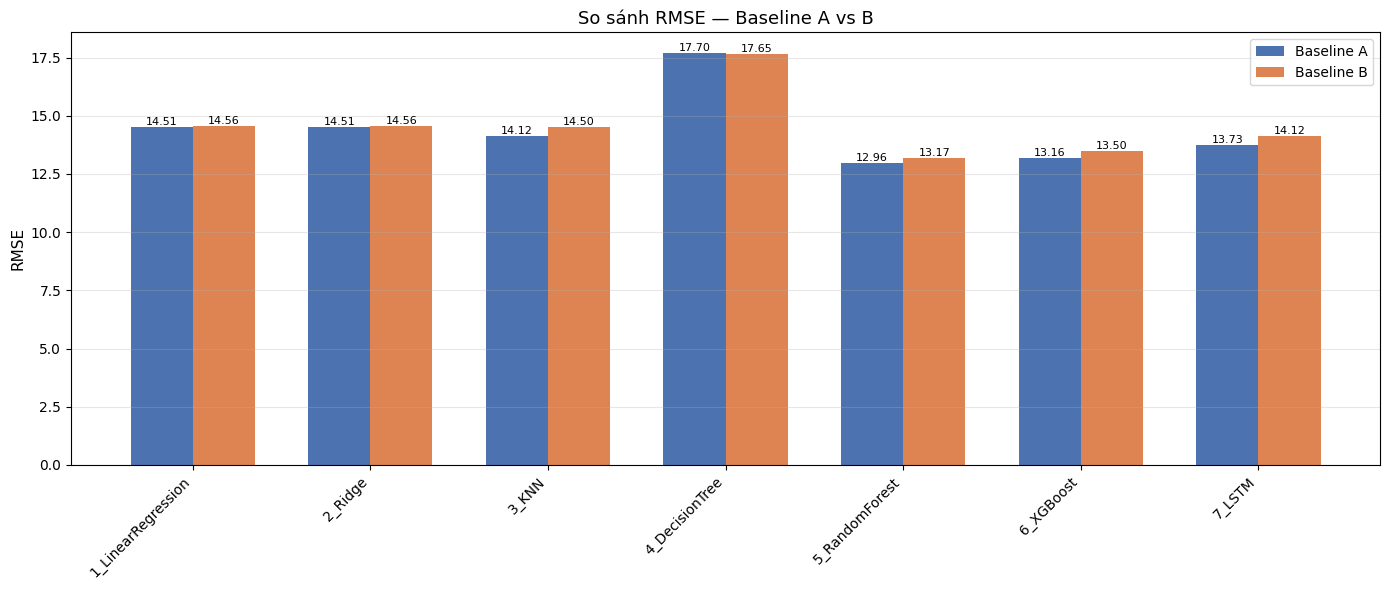

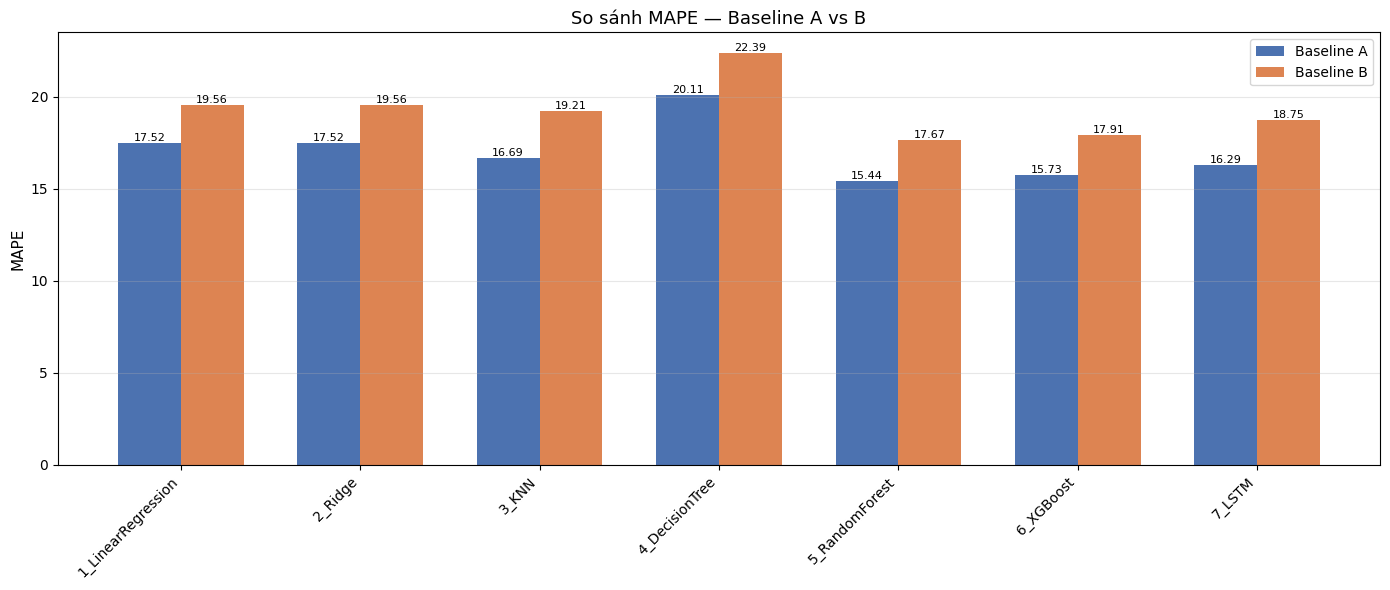

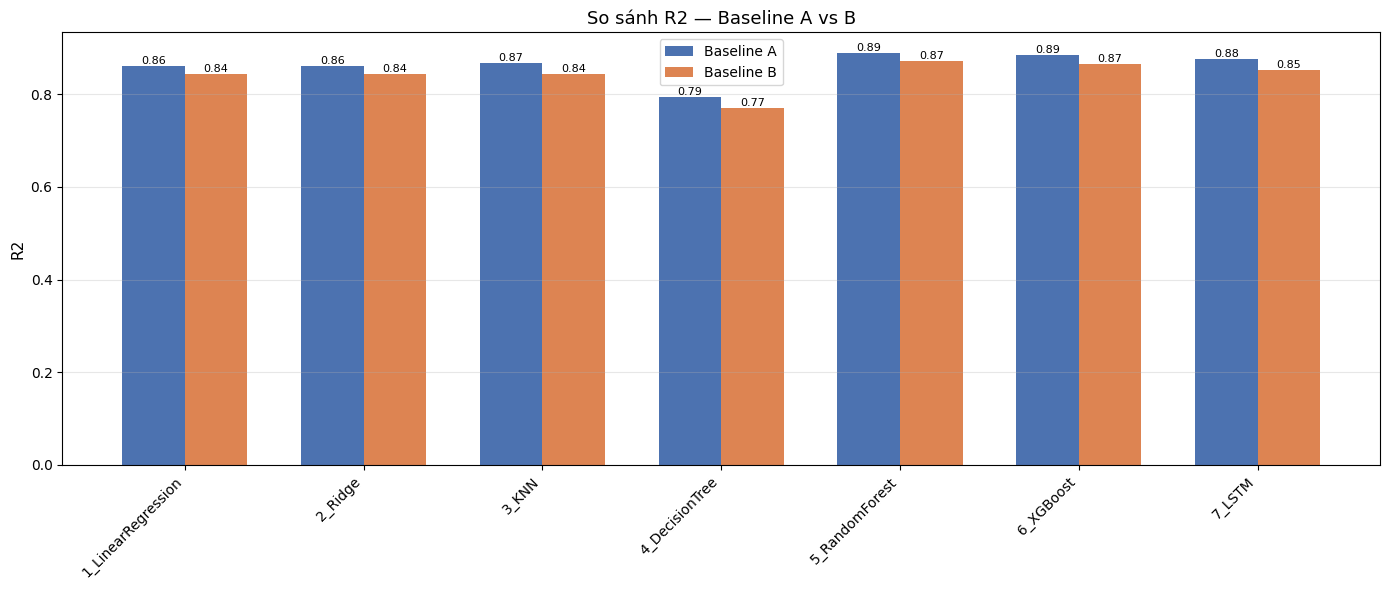

In [27]:
comparison.plot_comparison_all_metrics(
    results_a, results_b,
    save_dir=CONFIG['images_dir']
)

### 6.3. Radar Chart — R²

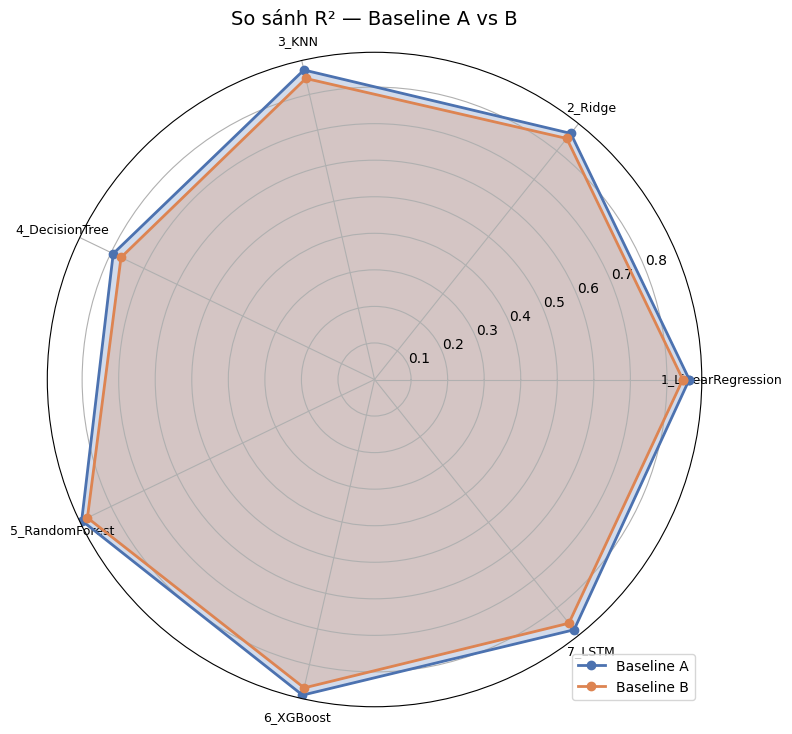

In [28]:
comparison.plot_comparison_radar(
    results_a, results_b,
    save_dir=CONFIG['images_dir']
)

### 6.4. Actual vs Predicted — Mô hình tốt nhất

🏆 Best Baseline A: 5_RandomForest
🏆 Best Baseline B: 5_RandomForest


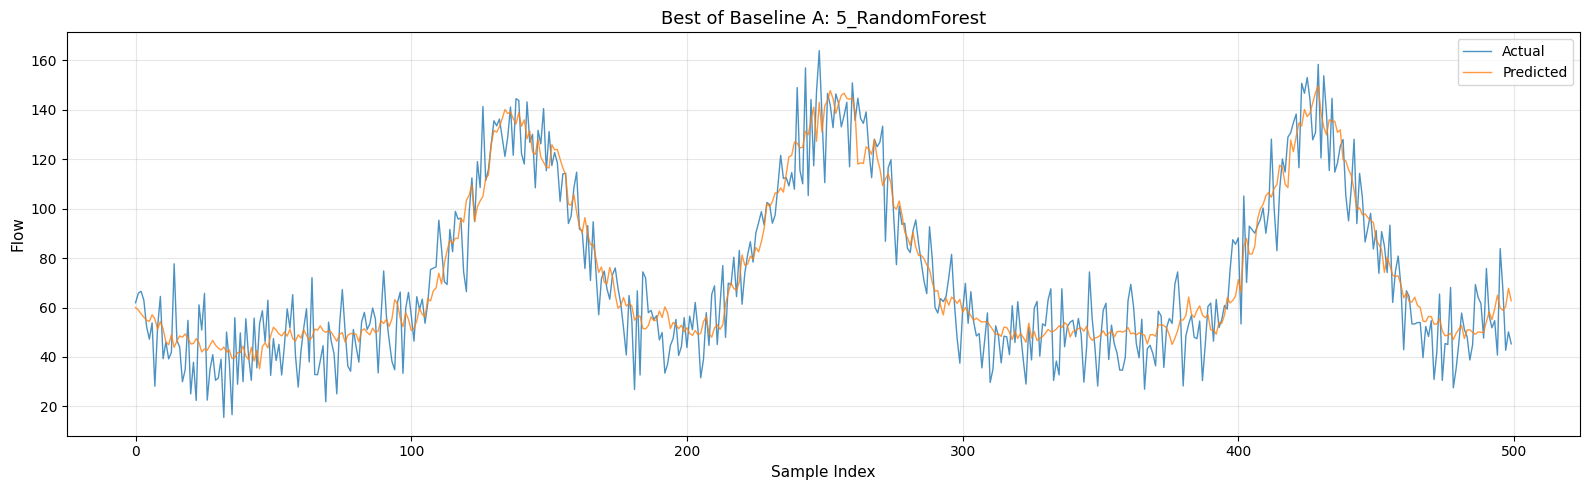

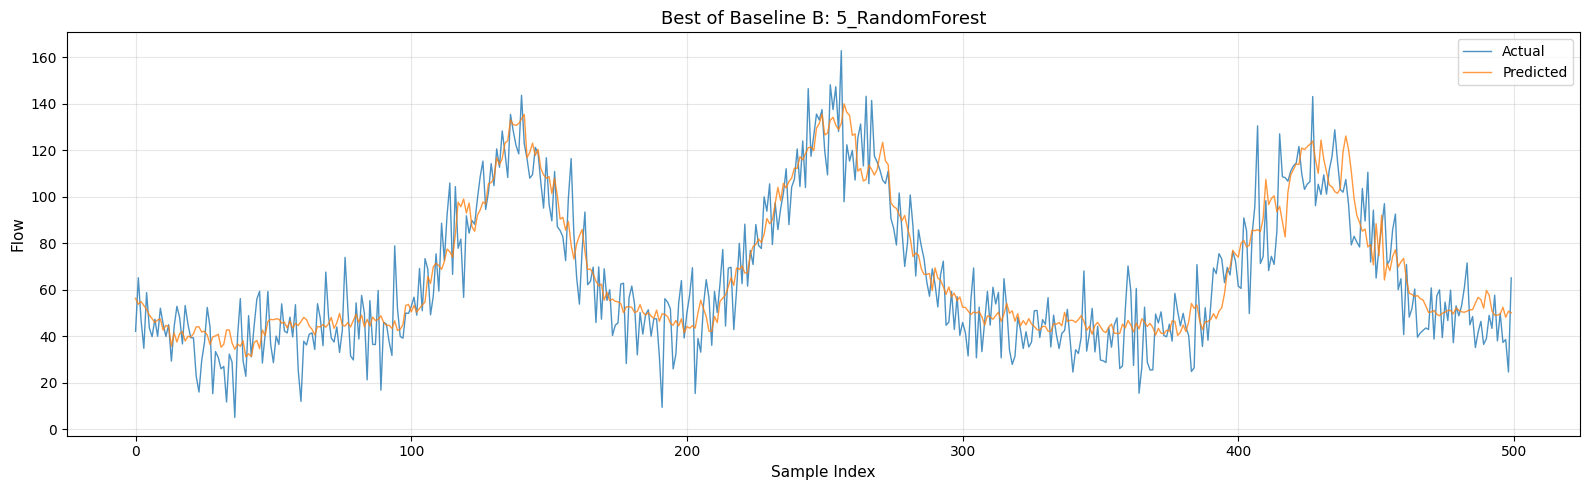

In [29]:
# Tìm mô hình tốt nhất (RMSE thấp nhất) cho mỗi baseline
best_a_name = results_a.loc[results_a['test_RMSE'].idxmin(), 'model']
best_b_name = results_b.loc[results_b['test_RMSE'].idxmin(), 'model']

print(f'🏆 Best Baseline A: {best_a_name}')
print(f'🏆 Best Baseline B: {best_b_name}')

# Vẽ Actual vs Predicted cho mô hình tốt nhất
viz.plot_actual_vs_predicted(
    y_test_a, trained_a[best_a_name]['y_pred_test'],
    title=f'Best of Baseline A: {best_a_name}',
    save_path=f"{CONFIG['images_dir']}/best_A.png"
)
viz.plot_actual_vs_predicted(
    y_test_b, trained_b[best_b_name]['y_pred_test'],
    title=f'Best of Baseline B: {best_b_name}',
    save_path=f"{CONFIG['images_dir']}/best_B.png"
)

### 6.5. Nhận xét & Kết luận

In [30]:
conclusion = comparison.generate_conclusion(results_a, results_b)

📋 NHẬN XÉT & KẾT LUẬN

🏆 Mô hình tốt nhất Baseline A: 5_RandomForest
   RMSE=12.96, MAE=10.28, R²=0.8893

🏆 Mô hình tốt nhất Baseline B: 5_RandomForest
   RMSE=13.17, MAE=10.47, R²=0.8719

📊 RMSE trung bình: A=14.38, B=14.58
   → Baseline A có kết quả dự báo tốt hơn tổng thể.

📝 So sánh chi tiết từng mô hình:
   1_LinearRegression: A=14.51 vs B=14.56 → Baseline A tốt hơn (chênh 0.05)
   2_Ridge: A=14.51 vs B=14.56 → Baseline A tốt hơn (chênh 0.05)
   3_KNN: A=14.12 vs B=14.50 → Baseline A tốt hơn (chênh 0.38)
   4_DecisionTree: A=17.70 vs B=17.65 → Baseline B tốt hơn (chênh 0.04)
   5_RandomForest: A=12.96 vs B=13.17 → Baseline A tốt hơn (chênh 0.21)
   6_XGBoost: A=13.16 vs B=13.50 → Baseline A tốt hơn (chênh 0.34)
   7_LSTM: A=13.73 vs B=14.12 → Baseline A tốt hơn (chênh 0.39)


---
## Kết thúc

Toàn bộ kết quả đã được lưu tại:
- **Biểu đồ**: `resultImages/`
- **Mô hình**: `models/`
- **Dữ liệu sạch**: `__datasets-clean/`

Chạy `demo.ipynb` để xem Dashboard trực quan.